# Notebook 6 : application au labyrinthe

On utilise le solveur validé (notebooks 2 à 5) avec le champ de vitesses du notebook 1.

**Fichiers nécessaires dans le même dossier** : `U.npy`, `V.npy`, `out_domain.txt`, `advection.py`.

**Rappel des conditions aux limites pour c** :
- entrée : concentration imposée `c = 1` (imposée comme un flux `V·c_in` sur la face d'entrée),
- sortie : sortie libre (flux avec la valeur de la cellule),
- parois : flux nul (vitesse nulle sur les faces contre un mur).

**Unités** : les vitesses sont normalisées (vitesse max = 1, dx = 1), donc les temps sont en « cellules / vitesse max ».

In [9]:
import os

os.chdir(r"C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire")

print(os.getcwd())

C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('figures', exist_ok=True)
from advection import *

U, V, dom = charger()
fluid, inlet, outlet = preparer_labyrinthe(dom)
Ny, Nx = dom.shape
print("grille :", Ny, "x", Nx, " cellules fluides :", fluid.sum())
print("entrée : ligne", inlet[0], "colonnes", inlet[1])
print("sortie : ligne", outlet[0], "colonnes", outlet[1])
print("vitesse max :", max(np.abs(U).max(), np.abs(V).max()))

grille : 502 x 502  cellules fluides : 209276
entrée : ligne 1 colonnes [228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 247 248]
sortie : ligne 500 colonnes [253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270
 271 272 273]
vitesse max : 1.0


## 1. Vérification avant de lancer

Un champ **c = 1 partout** doit rester constant. Ici il ne l'est qu'à la divergence résiduelle des vitesses près : cette valeur indique l'ampleur de la source ou du puits parasite dû à la précision de φ.

In [14]:
dmax, pos = test_champ_constant(U, V, dom)
print("Test c = 1 : max |dc/dt| =", dmax, "à la position", pos)
cfl = 0.5
print("Pas de temps pour CFL =", cfl, ":", pas_de_temps(U, V, 1.0, 1.0, cfl))

Test c = 1 : max |dc/dt| = 7.337315379275551e-13 à la position (98, 179)
Pas de temps pour CFL = 0.5 : 0.348131967612505


## 2. Scénario A : injection continue

On injecte c = 1 à l'entrée en permanence, et on arrête dès que la concentration de sortie atteint 99 %. Ce premier calcul donne l'échelle de temps du labyrinthe. La concentration de sortie est la moyenne pondérée par le débit sur les faces de sortie : c'est la **courbe de percée**.

In [17]:
c0 = np.zeros(dom.shape)
t_max = 20000.0                      # borne de sécurité (le calcul s'arrête avant, à c_sortie = 0.99)
A = simuler(c0, U, V, t_end=t_max, cfl=cfl, schema='upwind', temps='euler',
            inlet=inlet, outlet=outlet, c_in=1.0, fluid=fluid,
            arret_sortie=0.99, progress=True)

t10 = temps_arrivee(A['temps'], A['c_sortie'], 0.1)
t50 = temps_arrivee(A['temps'], A['c_sortie'], 0.5)
t90 = temps_arrivee(A['temps'], A['c_sortie'], 0.9)
t99 = A['t_final']
print(f"Temps pour que la sortie atteigne 10 %, 50 %, 90 %, 99 % : {t10:.1f}  {t50:.1f}  {t90:.1f}  {t99:.1f}")
print(f"Nombre de pas : {A['n']}, temps de calcul : {A['duree']:.2f} s")

   10.0 %  | pas 5745/57450 | ecoule   96.0 s | restant ~ 864.2 s
   20.0 %  | pas 11490/57450 | ecoule  168.1 s | restant ~ 672.2 s
   30.0 %  | pas 17235/57450 | ecoule  219.8 s | restant ~ 512.8 s
   40.0 %  | pas 22980/57450 | ecoule  275.1 s | restant ~ 412.7 s
   50.0 %  | pas 28725/57450 | ecoule  317.4 s | restant ~ 317.4 s
   60.0 %  | pas 34470/57450 | ecoule  365.1 s | restant ~ 243.4 s
   70.0 %  | pas 40215/57450 | ecoule  407.7 s | restant ~ 174.7 s
   80.0 %  | pas 45960/57450 | ecoule  449.4 s | restant ~ 112.4 s
   90.0 %  | pas 51705/57450 | ecoule  500.8 s | restant ~  55.6 s
  100.0 %  | pas 57450/57450 | ecoule  548.2 s | restant ~   0.0 s
Temps pour que la sortie atteigne 10 %, 50 %, 90 %, 99 % : 5796.0  6716.9  9762.3  20000.0
Nombre de pas : 57450, temps de calcul : 548.19 s


Si `t_final` vaut `t_max`, c'est que le traceur n'est pas arrivé à la sortie : augmente `t_max`.

### Bilan de masse

La masse dans le domaine doit être égale à ce qui est entré moins ce qui est sorti, à la précision machine : c'est la conséquence de la forme conservative.

In [19]:
masse = A['masse'][-1]
bilan = A['m_in'][-1] - A['m_out'][-1]
print(f"Masse dans le domaine      : {masse:.6f}")
print(f"Masse entrée - masse sortie : {bilan:.6f}")
print(f"Erreur de conservation      : {abs(masse - bilan):.2e}")
print(f"c min = {A['cmin'].min():.3e}   c max = {A['cmax'].max():.6f}   (l'upwind doit rester dans [0, 1])")

Masse dans le domaine      : 52566.399647
Masse entrée - masse sortie : 52566.399647
Erreur de conservation      : 8.88e-08
c min = 0.000e+00   c max = 1.000000   (l'upwind doit rester dans [0, 1])


### Instantanés

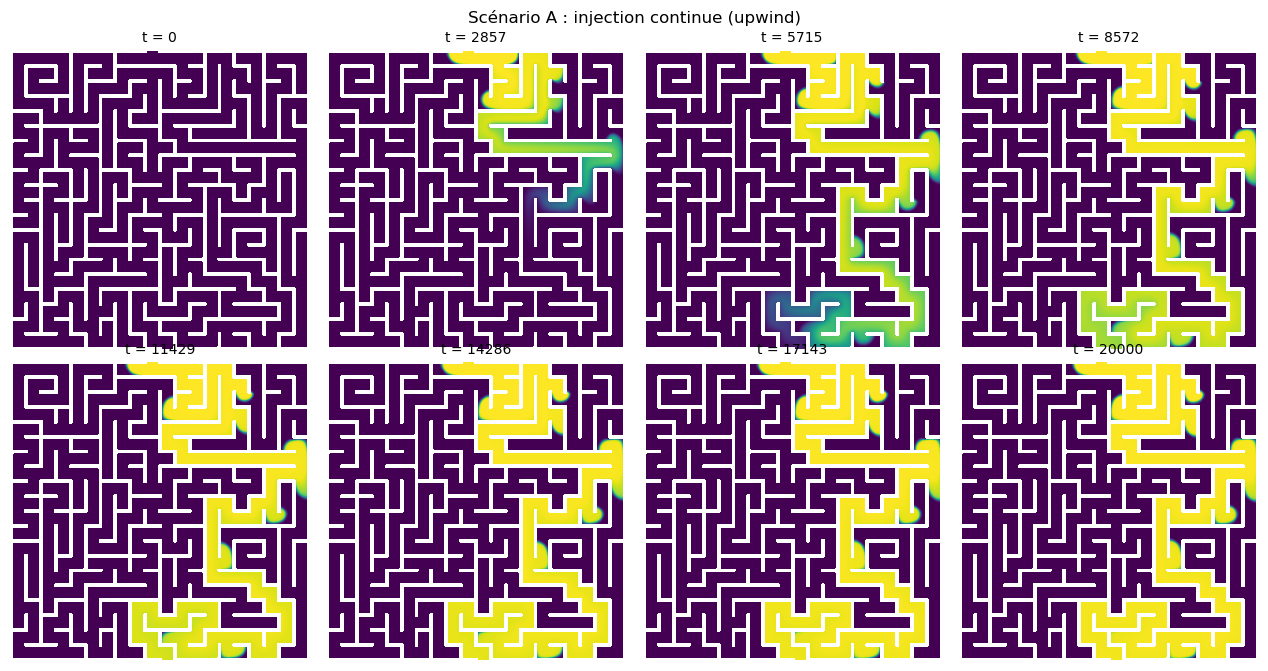

In [21]:
def afficher_snaps(snaps, dom, titre, fichier=None, ncol=4):
    fl = dom > 0
    n = len(snaps)
    nrow = int(np.ceil(n / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.4 * nrow))
    axs = np.atleast_1d(axs).ravel()
    for ax, (t, cc) in zip(axs, snaps):
        im = ax.imshow(np.where(fl, cc, np.nan), vmin=0, vmax=1)
        ax.set_title(f"t = {t:.0f}", fontsize=10); ax.axis('off')
    for ax in axs[n:]:
        ax.axis('off')
    fig.suptitle(titre)
    plt.tight_layout()
    if fichier:
        plt.savefig(fichier, dpi=200, bbox_inches='tight')
    plt.show()

# on relance le même calcul en gardant des instantanés régulièrement espacés
A2 = simuler(c0, U, V, t_end=t99, cfl=cfl, schema='upwind', temps='euler',
             inlet=inlet, outlet=outlet, c_in=1.0, fluid=fluid,
             snap_times=np.linspace(0, t99, 8))
afficher_snaps(A2['snaps'], dom, "Scénario A : injection continue (upwind)", 'figures/labyrinthe_A.png')

### Courbe de percée

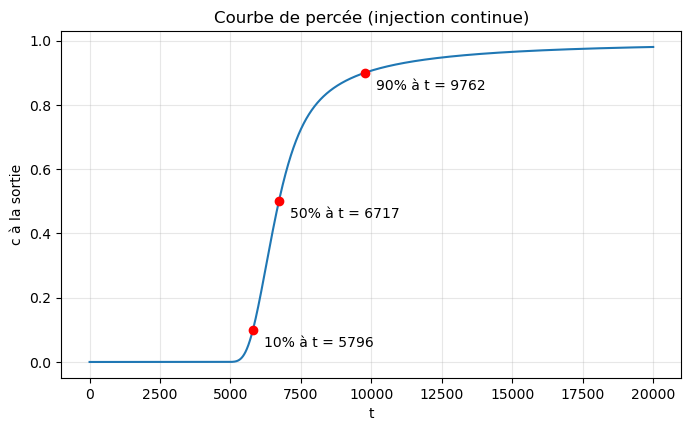

In [23]:
plt.figure(figsize=(8, 4.5))
plt.plot(A['temps'], A['c_sortie'])
for seuil, t_s in [(0.1, t10), (0.5, t50), (0.9, t90)]:
    plt.plot(t_s, seuil, 'ro')
    plt.annotate(f"{seuil:.0%} à t = {t_s:.0f}", (t_s, seuil), textcoords="offset points", xytext=(8, -12))
plt.xlabel("t"); plt.ylabel("c à la sortie"); plt.title("Courbe de percée (injection continue)")
plt.grid(True, alpha=0.3)
plt.savefig('figures/percee_A.png', dpi=200, bbox_inches='tight')
plt.show()

**À observer** : la concentration de sortie ne monte pas brutalement de 0 à 1, elle monte progressivement. Cet étalement a deux causes : la dispersion physique due aux vitesses différentes dans le labyrinthe (le fluide qui longe l'intérieur des coudes va plus vite que celui qui longe l'extérieur), et la **diffusion numérique** de l'upwind. Le notebook 7 permet de séparer les deux en comparant avec un schéma d'ordre 2.

## 3. Scénario B : un paquet de traceur

On injecte c = 1 seulement pendant un temps `t_inj` (30 % du temps de percée à 50 %), puis plus rien. Le paquet traverse le labyrinthe : on suit sa forme, sa dispersion et son passage à la sortie.

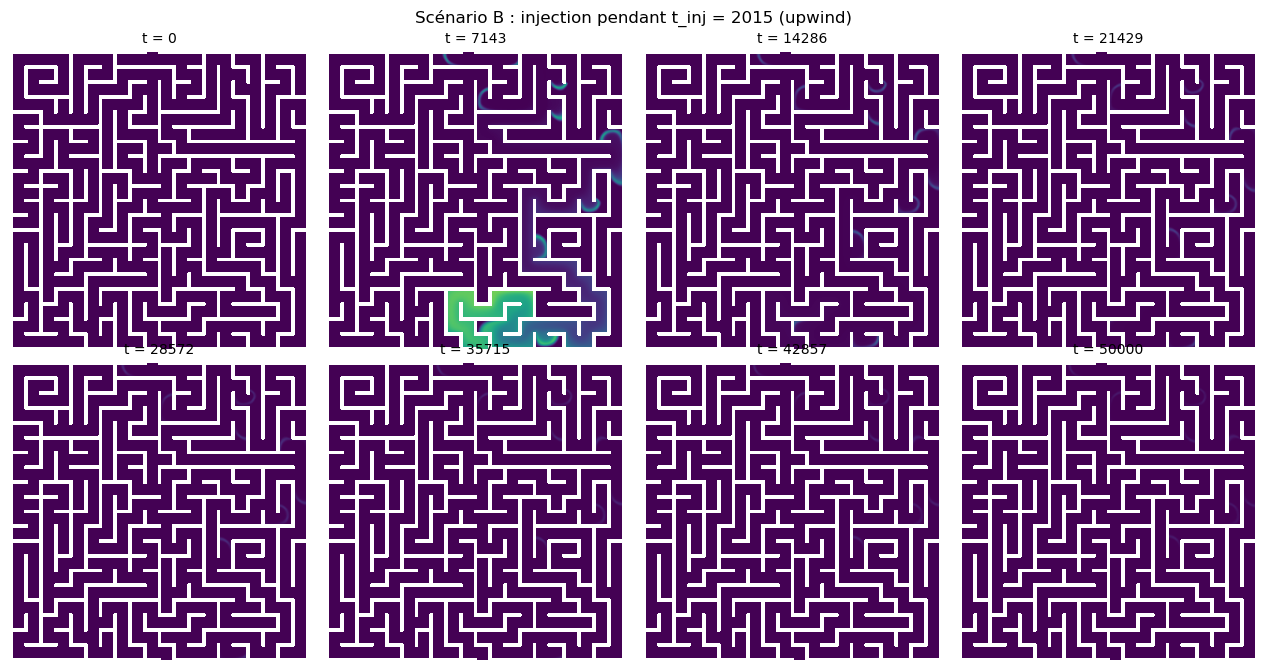

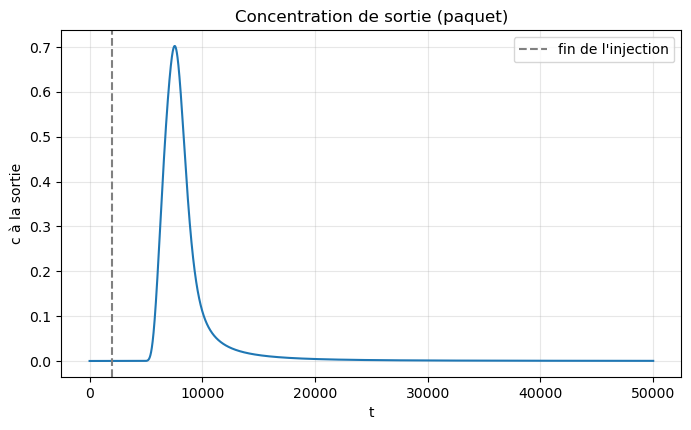

Masse injectée au total       : 14102.217
Masse sortie                  : 14029.456
Masse restante dans le domaine : 72.761
Concentration maximale à la sortie : 0.702  (initialement 1 à l'entrée)
Erreur de conservation : 1.27e-09


In [25]:
t_inj = 0.3 * t50
B = simuler(c0, U, V, t_end=2.5 * t99, cfl=cfl, schema='upwind', temps='euler',
            inlet=inlet, outlet=outlet, c_in=1.0, t_inj=t_inj, fluid=fluid,
            snap_times=np.linspace(0, 2.5 * t99, 8))
afficher_snaps(B['snaps'], dom, f"Scénario B : injection pendant t_inj = {t_inj:.0f} (upwind)", 'figures/labyrinthe_B.png')

plt.figure(figsize=(8, 4.5))
plt.plot(B['temps'], B['c_sortie'])
plt.axvline(t_inj, color='gray', ls='--', label="fin de l'injection")
plt.xlabel("t"); plt.ylabel("c à la sortie"); plt.title("Concentration de sortie (paquet)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('figures/percee_B.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Masse injectée au total       : {B['m_in'][-1]:.3f}")
print(f"Masse sortie                  : {B['m_out'][-1]:.3f}")
print(f"Masse restante dans le domaine : {B['masse'][-1]:.3f}")
print(f"Concentration maximale à la sortie : {np.nanmax(B['c_sortie']):.3f}  (initialement 1 à l'entrée)")
print(f"Erreur de conservation : {abs(B['masse'][-1] - (B['m_in'][-1] - B['m_out'][-1])):.2e}")